# Salary Prediction using Simple Linear Regression
Built from scratch using NumPy — no ML libraries used.

In [110]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # data visualization

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

/kaggle/input/datasets/abhishek14398/salary-dataset-simple-linear-regression/Salary_dataset.csv


## Loading Dataset and Dataset Overview
Removing unnecessary columns and reading CSV file.

In [111]:
df = pd.read_csv("/kaggle/input/datasets/abhishek14398/salary-dataset-simple-linear-regression/Salary_dataset.csv")
df = df.drop(columns = ["Unnamed: 0"]) # removed unnecessary column
pd.concat([df.head(3), df.tail(3)]) # printed first and last 3 rows

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
27,9.7,112636.0
28,10.4,122392.0
29,10.6,121873.0


## Visualising the Raw Data
Plotting experience vs salary to check if a linear relationship exists.

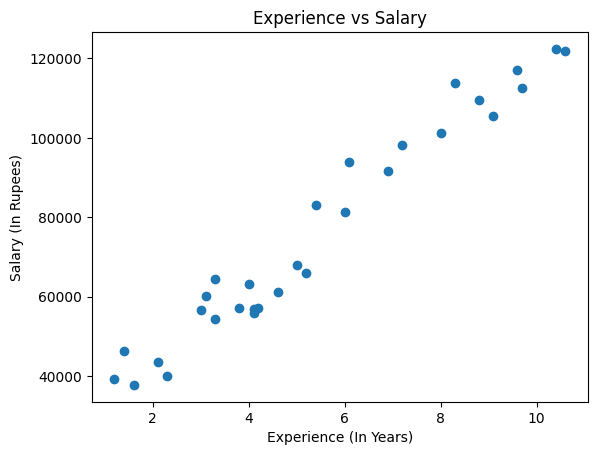

In [112]:
plt.scatter(df["YearsExperience"], df["Salary"])
plt.title("Experience vs Salary")
plt.xlabel("Experience (In Years)")
plt.ylabel("Salary (In Rupees)")
plt.show()

## Building the Design Matrix

We want to solve:

$$A\boldsymbol{\theta} = \mathbf{y}$$

where $A$ is the design matrix (experience + bias column) of shape (n, 2) and $\mathbf{y}$ is the salary vector.

In [113]:
A = np.column_stack((df["YearsExperience"], np.ones(len(df))))
A.shape

(30, 2)

## Target Vector
y is the salary column reshaped into a column vector of shape (n, 1).

In [114]:
y = np.column_stack(df["Salary"])
y = y.reshape(-1, 1)
y.shape

(30, 1)

## Solving using the Normal Equation
No sklearn, no ML library. We derive the best fit line purely using linear algebra.

The Normal Equation solves for coefficients directly:

$$\boldsymbol{\theta} = (A^T A)^{-1} A^T \mathbf{y}$$

In [115]:
theta = np.linalg.inv(np.transpose(A) @ A) @ np.transpose(A) @ y
theta

array([[ 9449.96232146],
       [24848.20396652]])

In [116]:
slope = theta[0, 0]
intercept = theta[1, 0]
print(f"Slope: {slope:.2f}, Intercept: {intercept:.2f}")

Slope: 9449.96, Intercept: 24848.20


In [117]:
reg_line = slope * df["YearsExperience"] + intercept

## Fitting the Regression Line
Using the slope and intercept to draw the best fit line over the data.

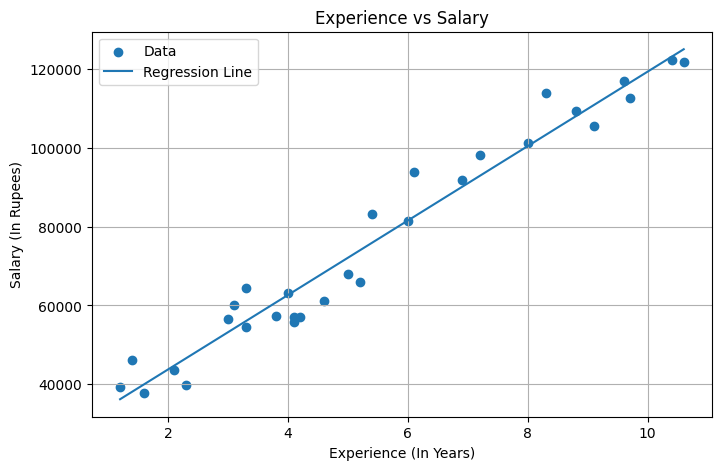

In [118]:
plt.figure(figsize=(8,5))
plt.scatter(df["YearsExperience"], df["Salary"], label = "Data")

plt.plot(
    df["YearsExperience"],
    reg_line,
    label = "Regression Line"
)

plt.title("Experience vs Salary")
plt.xlabel("Experience (In Years)")
plt.ylabel("Salary (In Rupees)")
plt.grid(True)
plt.legend()
plt.show()

## Making a Prediction
Using the learned coefficients to predict salary:

$$\hat{y} = \theta_1 x + \theta_0$$

where $x$ is years of experience, $\theta_1$ is the slope and $\theta_0$ is the intercept.

In [119]:
exp = float(input("Enter your Experience (in Years) : "))
salary = slope * exp + intercept
print("Salary : " + str(salary) + " rupees")

Enter your Experience (in Years) :  5


Salary : 72098.01557379856 rupees
